In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build the vocabulary of the characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()} 

In [21]:
#build the dataset

block_size = 3
X, Y = [], []
for w in words:
    
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [31]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [22]:
C = torch.randn((27,2))

In [23]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [8]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [9]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)

In [10]:
h

tensor([[-0.3711, -0.9661, -0.8072,  ...,  0.9962,  0.2025,  0.9944],
        [ 0.7285, -0.8355,  0.9848,  ...,  0.9713,  0.0773,  0.9944],
        [-0.9072,  0.1562,  0.9983,  ...,  0.7282,  0.7123, -0.9825],
        ...,
        [ 0.9963,  0.9595,  0.2596,  ...,  0.6079, -0.9493,  0.9948],
        [-0.9794, -0.9919, -0.3472,  ...,  0.9211, -0.6235,  0.9941],
        [ 0.9997,  0.9933, -0.5077,  ...,  0.9996,  0.8655, -0.0370]])

In [11]:
w2 = torch.randn((100,27))
b2 = torch.randn(27)

In [12]:
logits = h @ w2  + b2

In [13]:
logits.shape

torch.Size([32, 27])

In [14]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)

In [15]:
prob.shape

torch.Size([32, 27])

In [32]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [73]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
w1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
w2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [74]:
sum(p.nelement() for p in parameters)

11897

In [75]:
for p in parameters:
    p.requires_grad = True

In [76]:
stepi = []
lossi = []

In [85]:

for i in range(50000):

    #minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 30) @ w1 + b1) # (32,100)
    logits = h @ w2 + b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])
    
    #backward Pass
    for p in parameters:
        p.grad =None
    loss.backward()
    #update
    lr = 0.01
    for p in parameters:
        p.data += - lr* p.grad

    #keep track
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())

2.0352704524993896


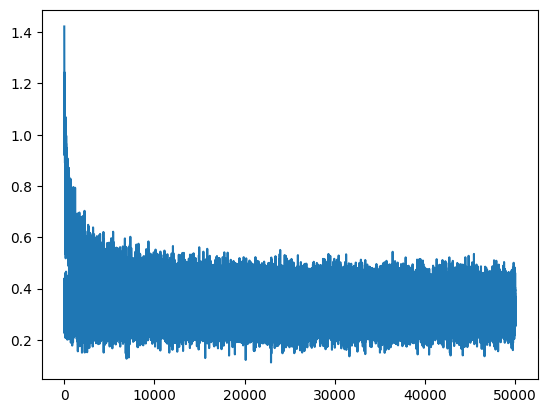

In [86]:
plt.plot(stepi, lossi)

In [87]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ w1 + b1) # (32,100)
logits = h @ w2 + b2 #(32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1750, grad_fn=<NllLossBackward0>)

In [88]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ w1 + b1) # (32,100)
logits = h @ w2 + b2 #(32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1709, grad_fn=<NllLossBackward0>)

In [91]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ w1 + b1)
      logits = h @ w2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amorie.
khirmri.
reh.
caspansha.
jazonen.
amerric.
kaeli.
ner.
kia.
chaiir.
kaleigh.
ham.
jori.
quinn.
shoilea.
jadique.
jero.
dearyni.
jace.
